<a href="https://colab.research.google.com/github/raditya12/MachineLearning/blob/master/Quiz1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pengantar

Pada Kuis 1 ini Anda diminta untuk melakukan proses explorartory data analysis (EDA) dan pra pengolahan data pada dataset "Census Income". Dataset ini merupakan data tabular yang memiliki beberapa nilai yang hilang (missing value) dan nama variabel (fitur) yang perlu disesuaikan.

Untuk membantu Anda, notebook ini akan memberikan kode awal untuk proses download data, load data, dan inspeksi informasi terkait dengan metadata.

# Load Data and Inspect Metadata

In [1]:
# Jalankan di Google Colab; library dasar dan TensorFlow sudah tersedia.
!pip install -q ucimlrepo

In [2]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [3]:
adult_income = fetch_ucirepo(id=2)

In [4]:
# Data
X = adult_income.data.features
y = adult_income.data.targets

# Concate Features and Target
df = pd.concat([X, y], axis=1)

# Show Top 5
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
# Data Size
df.shape

(48842, 15)

In [6]:
# Inspect metadata
adult_income.metadata

{'uci_id': 2,
 'name': 'Adult',
 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult',
 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv',
 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ',
 'area': 'Social Science',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 48842,
 'num_features': 14,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'],
 'target_col': ['income'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1996,
 'last_updated': 'Tue Sep 24 2024',
 'dataset_doi': '10.24432/C5XW20',
 'creators': ['Barry Becker', 'Ronny Kohavi'],
 'intro_paper': None,
 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was ex

# Bagian 1 - Data Loading dan Data Imputation

## Soal 1 (5 poin)
1.   Lakukan inspeksi profile data
2.   **Variabel apa** yang memiliki **nilai yang hilang** (missing value) dan **berapa** jumlahnya?



In [7]:
# '?' dan NaN sama-sama merupakan missing value.
df = df.replace('?', np.nan)
df.info()
display(df.describe())
print("Jumlah missing value:")
print(df.isnull().sum())
# workclass: 2799, occupation: 2809, native-country: 857.
# Kolom lain tidak memiliki missing value.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       46043 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      46033 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  47985 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


Jumlah missing value:
age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
dtype: int64


## Soal 2 (5 poin)
1. Lakukan proses data imputation pada fitur yang memiliki data yang hilang
2. Cek kembali apakah masih terdapat data yang hilang

In [8]:
# Isi kolom kategorikal yang kosong dengan modus masing-masing.
for col in ['workclass', 'occupation', 'native-country']:
    df[col] = df[col].fillna(df[col].mode().iloc[0])

print(df.isnull().sum())  # Semua kolom bernilai 0.

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


## Soal 3 (10 poin)
Inspeksi semua fitur kualitatif. Jika terdapat value yang **tidak sesuai**, **ganti dengan 'Others'** atau yang sesuai atau jika terdapat duplikasi karena **kesalahan penulisan**, lakukan penyesuaian.

In [9]:
# Inspeksi semua kolom kualitatif.
cat_cols = df.select_dtypes(include=['object', 'string']).columns
for col in cat_cols:
    df[col] = df[col].str.strip()
    print(col, df[col].unique())

# Satukan label income yang berbeda karena titik di belakang.
df['income'] = df['income'].replace({'<=50K.': '<=50K', '>50K.': '>50K'})
# Perbaiki ejaan negara kategori sah lainnya tetap dipertahankan.
df['native-country'] = df['native-country'].replace({
    'Columbia': 'Colombia',
    'Trinadad&Tobago': 'Trinidad-and-Tobago',
    'Holand-Netherlands': 'Netherlands',
    'Hong': 'Hong-Kong'
})
print("Income setelah perbaikan:", df['income'].unique())
print("Negara setelah perbaikan:", df['native-country'].unique())

workclass ['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov'
 'Self-emp-inc' 'Without-pay' 'Never-worked']
education ['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']
marital-status ['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']
occupation ['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' 'Protective-serv'
 'Armed-Forces' 'Priv-house-serv']
relationship ['Not-in-family' 'Husband' 'Wife' 'Own-child' 'Unmarried' 'Other-relative']
race ['White' 'Black' 'Asian-Pac-Islander' 'Amer-Indian-Eskimo' 'Other']
sex ['Male' 'Female']
native-country ['United-States' 'Cuba' 'Jamaica' 'India' 'Mexico' 'South' 'Puerto-Rico'
 'Honduras' 'England' 'Canada' 'Germany' 'I

# Bagian 2 - Visual Inspection



## Soal 1 - Visualisasi Data (20 poin)
Lakukan inspeksi visual pada,
1. Pada kolom 'age' dengan menggunakan histrogram
2. Pada kolom 'education' education menggunakan barchart
3. Pada kolom 'income' terhadap 'hours_per_week' menggunakan boxplot (kelompokkan berdasarkan kelompok income)
4. Pada kolom 'age' terhadap 'capital-gain' dan 'capital-loss' dengan lineplot (1 lineplot 2 data)

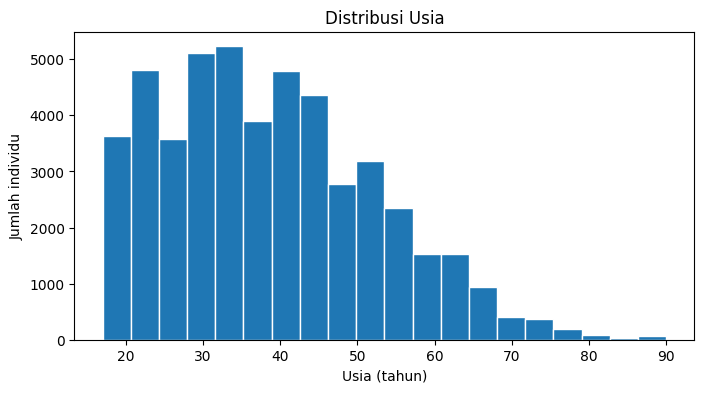

In [10]:
#Histogram
plt.figure(figsize=(8, 4))
plt.hist(df['age'], bins=20, edgecolor='white')
plt.title('Distribusi Usia')
plt.xlabel('Usia (tahun)')
plt.ylabel('Jumlah individu')
plt.show()

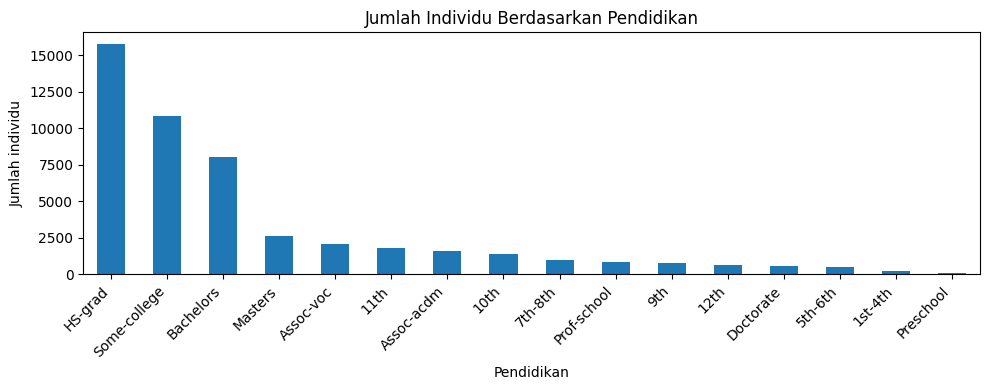

In [11]:
#Barchart
df['education'].value_counts().plot(kind='bar', figsize=(10, 4))
plt.title('Jumlah Individu Berdasarkan Pendidikan')
plt.xlabel('Pendidikan')
plt.ylabel('Jumlah individu')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

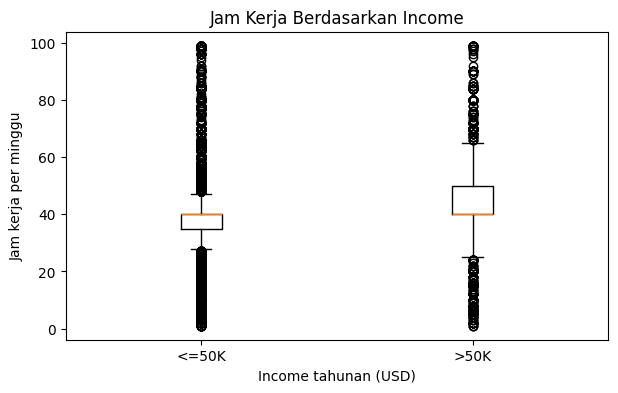

In [12]:
#Boxplot
kelompok = ['<=50K', '>50K']
jam_rendah = df[df['income'] == '<=50K']['hours-per-week']
jam_tinggi = df[df['income'] == '>50K']['hours-per-week']
plt.figure(figsize=(7, 4))
plt.boxplot([jam_rendah, jam_tinggi])
plt.xticks([1, 2], kelompok)
plt.title('Jam Kerja Berdasarkan Income')
plt.xlabel('Income tahunan (USD)')
plt.ylabel('Jam kerja per minggu')
plt.show()

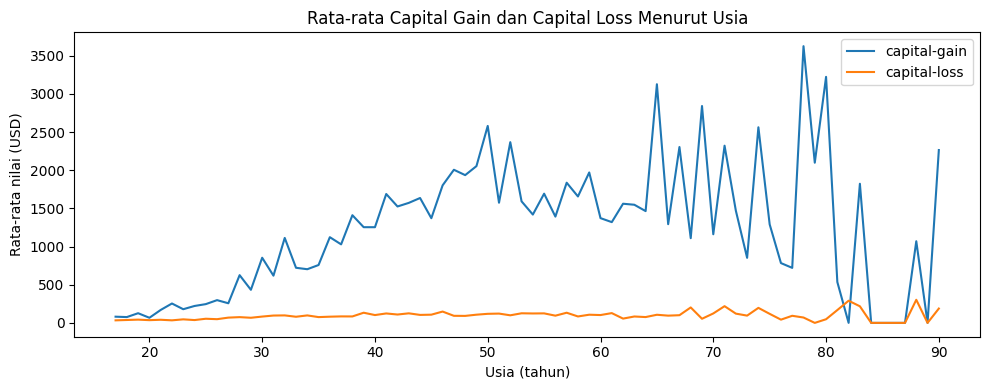

In [13]:
# Lineplot
modal = df.groupby('age')[['capital-gain', 'capital-loss']].mean()
modal.plot(figsize=(10, 4))
plt.title('Rata-rata Capital Gain dan Capital Loss Menurut Usia')
plt.xlabel('Usia (tahun)')
plt.ylabel('Rata-rata nilai (USD)')
plt.tight_layout()
plt.show()

## Soal 2 - Analisis Visual (15 poin)
1. Fenomena apa yang terjadi pada distribusi data 'age'?
2. Jika terdapat data yang hilang pada variabel 'age', strategi apa yang Anda terapkan? Mengapa?
3. Berapa jumlah outlier pada setiap kategori 'income' berkaitan dengan 'hour-per-week'? Kategori apa yang paling banyak memiliki outlier?

In [14]:
# 1. Distribusi age condong ke kanan: lebih banyak individu dewasa muda,
#    sedangkan individu berusia lanjut lebih sedikit. Mean 38,64 > median 37.
# 2. Jika age kosong, gunakan median karena lebih tahan terhadap nilai
#    ekstrem daripada mean. Pada data ini tidak ada age yang kosong.
# 3. Dengan aturan 1,5 IQR per kategori, outlier <=50K berjumlah 11.706
#    dan >50K berjumlah 781. Kategori <=50K memiliki outlier terbanyak.
#    Outlier menurut IQR tidak otomatis berarti datanya salah.

# Hitung jumlah outlier untuk memverifikasi jawaban nomor 3.
for income in ['<=50K', '>50K']:
    jam = df[df['income'] == income]['hours-per-week']
    q1 = jam.quantile(0.25)
    q3 = jam.quantile(0.75)
    iqr = q3 - q1
    outlier = jam[(jam < q1 - 1.5 * iqr) | (jam > q3 + 1.5 * iqr)]
    print(income, ':', len(outlier), 'outlier')

<=50K : 11706 outlier
>50K : 781 outlier


# Bagian 3 - Encoding Variabel Kategorical

## Soal 1 (5 poin)
Lakukan encoding pada 'Sex' dan 'Income'. 'Income' merupakan variabel target

In [15]:
# Simpan hasil encoding terpisah agar grafik tetap bisa memakai label asli.
df_encoded = df.copy()
df_encoded['sex'] = df_encoded['sex'].map({'Female': 0, 'Male': 1})
df_encoded['income'] = df_encoded['income'].map({'<=50K': 0, '>50K': 1})
y = df_encoded['income']  # Target: 0 = <=50K, 1 = >50K.
df_encoded[['sex', 'income']].head()

,sex,income
0,1,0
1,1,0
2,1,0
3,1,0
4,0,0


# Bagian 4 - Analisis Korelasi

## Soal 1 (10 poin)
1. Lakukan analisis korelasi pada variabel 'age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', dan 'income' (yang sudah di-encoding)
2. Berdasarkan hasil korelasi, informasi apa yang dapat Anda interpretasikan?

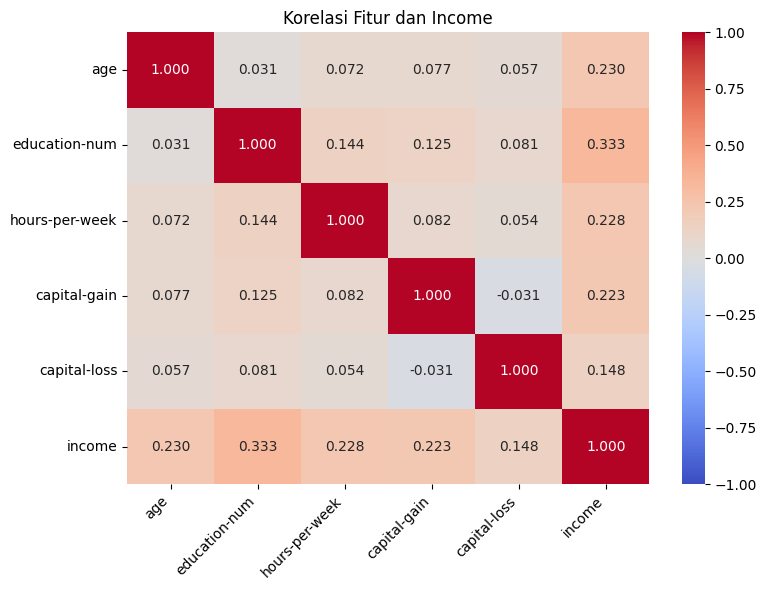

education-num     0.332613
age               0.230369
hours-per-week    0.227687
capital-gain      0.223013
capital-loss      0.147554
Name: income, dtype: float64


In [16]:
kolom = ['age', 'education-num', 'hours-per-week',
         'capital-gain', 'capital-loss', 'income']
corr = df_encoded[kolom].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Korelasi Fitur dan Income')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(corr['income'].drop('income').sort_values(ascending=False))

In [17]:
# education-num berkorelasi positif paling besar dengan income (0,333).
# Artinya, pendidikan lebih tinggi cenderung terkait income >50K.
# Korelasi age (0,230), hours-per-week (0,228), capital-gain (0,223),
# dan capital-loss (0,148) juga positif, tetapi relatif lemah.
# Tidak ada hubungan linear yang kuat antarfitur prediktor terpilih.
# Korelasi menunjukkan keterkaitan, bukan bukti sebab-akibat.

# Bagian 5 - Pra Pengolahan Data Pada Dataset MNIST

Pada bagian ini, Anda diminta untuk melakukan proses EDA dan pra pengolahan data sederhana pada dataset MNIST. Dataset MNIST merupakan data citra tulisan tangan untuk digil 0 hingga 9. Sebelum melakukan proses pengolahan, Anda akan dibantu dengan proses loading data dan inspeksi data.

Hints:
1. Hanya gunakan data **Test**
2. Anda perlu melakukan pengolahan terhadap semua data test (total 10k data). Anda dapat menggunakan function untuk mempermudah pekerjaan.

In [18]:
from tensorflow.keras.datasets import mnist

# Hanya gunakan data test sesuai instruksi soal.
_, (X_test, y_test) = mnist.load_data()
print("Test shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Test shape: (10000, 28, 28)


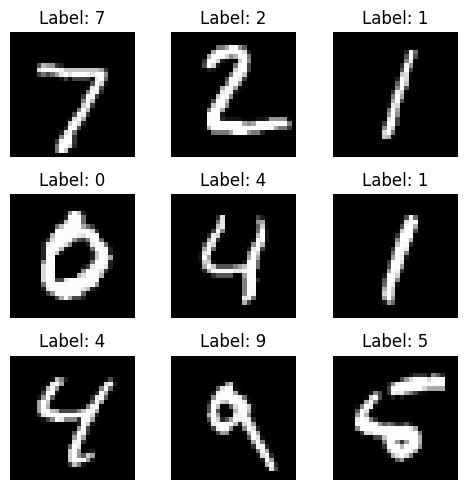

In [19]:
plt.figure(figsize=(5, 5))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f'Label: {y_test[i]}')
    plt.axis('off')
plt.tight_layout()
plt.show()

## Soal 1 (10 poin)
1. Lakukan proses **upsampling** citra menjadi ukuran 32x32
2. Tampilakan 5 data hasil proses **upsampling**

Hint: Anda harus membuat array kosong untuk menampung hasil upsampling. Replace pada array X_test tidak dapat dilakukan karena data disimpan dalam bentuk ndarray yang memiliki ukuran fix (10000, (28,28))

(10000, 32, 32)


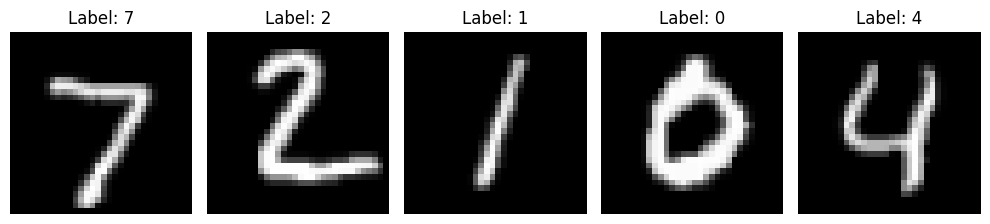

In [20]:
import cv2

# Array baru untuk menampung seluruh 10.000 citra hasil resize.
X_test_resized = np.empty((len(X_test), 32, 32), dtype=np.uint8)
for i in range(len(X_test)):
    X_test_resized[i] = cv2.resize(X_test[i], (32, 32))

print(X_test_resized.shape)  # (10000, 32, 32)
plt.figure(figsize=(10, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test_resized[i], cmap='gray')
    plt.title(f'Label: {y_test[i]}')
    plt.axis('off')
plt.tight_layout()
plt.show()

## Soal 2 (10 poin)
Lakukan normalisasi nilai citra tiap piksel menjadi rentang 0-1

In [21]:
# Normalisasi seluruh piksel dari 0-255 menjadi 0-1.
X_test_normalized = X_test_resized.astype(np.float32) / 255.0
print('Rentang piksel:', X_test_normalized.min(), '-', X_test_normalized.max())

Rentang piksel: 0.0 - 1.0


## Soal 3 (10 poin)
Ubah metriks citra menjadi array 1 dimensi. Lakukan pada semua data test yang sudah di resize dan normalisasi.

Hint: Anda harus membuat holder array kosong untuk menampung hasilnya.

In [22]:
# Holder sesuai petunjuk soal: satu baris berisi 32 x 32 = 1024 piksel.
X_test_flatten = np.empty((len(X_test_normalized), 1024), dtype=np.float32)
for i in range(len(X_test_normalized)):
    X_test_flatten[i] = X_test_normalized[i].flatten()

print('Seluruh data:', X_test_flatten.shape)  # (10000, 1024)
print('Satu citra:', X_test_flatten[0].shape)  # (1024,)
# Urutan citra tetap, sehingga labelnya tetap y_test.

Seluruh data: (10000, 1024)
Satu citra: (1024,)
